In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


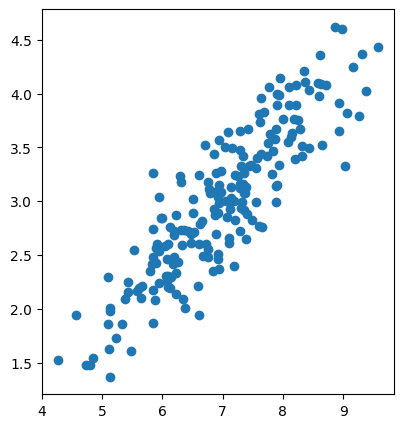

In [4]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(df['cgpa'],df['package'])


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X=df.iloc[:,0:1]
y=df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [33]:
X_test.shape

(60, 1)

In [34]:
li = LinearRegression()
li.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pred = li.predict(X_test)
r2_score(y_test,y_pred)

0.7525945592908275

In [8]:
b=li.intercept_
m=li.coef_

In [36]:
b,m

(np.float64(-0.980883767663578), array([0.57018094]))

In [9]:
m* 9.4 + b

array([4.37881706])

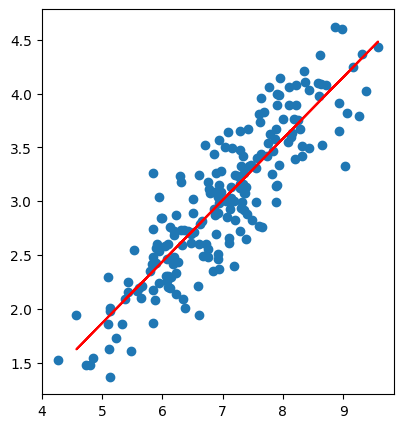

In [10]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,li.predict(X_train),color='r')


In [45]:
class ML:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        # add column 1s for intercept (bnote)
        X_train = np.insert(X_train,0,1,axis=1)

        beta = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)

        self.coef_ =beta[1:]
        self.intercept_ =beta[0]

    def predict(self,X_test):
        return self.intercept_ + np.dot(X_test,self.coef_)
        

In [46]:
lr = ML()

In [47]:
lr.fit(X_train,y_train)

In [49]:
y_pred= lr.predict(X_test)

In [50]:
r2_score(y_test,y_pred)

0.7525945592908277